In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [3]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Campaign_ID                        10000 non-null  object 
 1   Product_ID                         10000 non-null  object 
 2   Budget                             10000 non-null  float64
 3   Clicks                             10000 non-null  int64  
 4   Conversions                        10000 non-null  int64  
 5   Revenue_Generated                  10000 non-null  float64
 6   ROI                                10000 non-null  float64
 7   Customer_ID                        10000 non-null  object 
 8   Subscription_Tier                  10000 non-null  object 
 9   Subscription_Length                10000 non-null  int64  
 10  Flash_Sale_ID                      10000 non-null  object 
 11  Discount_Level                     10000 non-null  int6

,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25263.607524,2481.903600,498.978700,50038.627579,2.756365,18.016500,39.421000,100.689600,275.198346,2.500900
std,14350.085927,1435.973623,289.479495,28545.702337,1.296901,10.149666,17.212925,57.074015,129.218710,1.113249
min,500.440000,10.000000,1.000000,1002.080000,0.500000,1.000000,10.000000,1.000000,50.010000,1.000000
25%,12789.190000,1225.750000,247.000000,25264.255000,1.630000,9.000000,24.000000,52.000000,165.717500,2.000000
50%,25030.170000,2451.000000,499.000000,49513.815000,2.750000,18.000000,39.000000,101.000000,272.555000,2.000000
75%,37921.725000,3723.000000,751.000000,74507.157500,3.890000,27.000000,54.000000,150.000000,387.322500,3.000000
max,49999.630000,4999.000000,999.000000,99999.470000,5.000000,35.000000,69.000000,199.000000,499.970000,4.000000


In [4]:
df = df.drop_duplicates()

df = df.drop(columns=[
    'Campaign_ID',
    'Product_ID',
    'Customer_ID',
    'Flash_Sale_ID',
    'Bundle_ID',
    'Common_Keywords'
], errors='ignore')

df = df.dropna()

df.head()

,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Tier,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
0,41770.45,4946,73,15520.09,1.94,Premium,4,43,34,433.80,4
1,29900.93,570,510,30866.17,0.76,Premium,4,28,97,289.29,2
2,22367.45,3546,265,32585.62,1.41,Basic,9,51,160,462.87,4
3,29957.54,2573,781,95740.12,3.32,Premium,32,36,159,334.16,1
4,36277.19,818,79,81990.43,3.53,Standard,29,20,52,371.67,2


In [5]:
le = LabelEncoder()

df['Subscription_Tier'] = le.fit_transform(df['Subscription_Tier'])

df.head()

,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Tier,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
0,41770.45,4946,73,15520.09,1.94,1,4,43,34,433.80,4
1,29900.93,570,510,30866.17,0.76,1,4,28,97,289.29,2
2,22367.45,3546,265,32585.62,1.41,0,9,51,160,462.87,4
3,29957.54,2573,781,95740.12,3.32,1,32,36,159,334.16,1
4,36277.19,818,79,81990.43,3.53,2,29,20,52,371.67,2


In [6]:
X = df.drop(columns=['Revenue_Generated'])
y = df['Revenue_Generated']

X.head()

,Budget,Clicks,Conversions,ROI,Subscription_Tier,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
0,41770.45,4946,73,1.94,1,4,43,34,433.80,4
1,29900.93,570,510,0.76,1,4,28,97,289.29,2
2,22367.45,3546,265,1.41,0,9,51,160,462.87,4
3,29957.54,2573,781,3.32,1,32,36,159,334.16,1
4,36277.19,818,79,3.53,2,29,20,52,371.67,2


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 10)
Testing data: (2000, 10)


In [8]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,24756.218949,28601.119602,-0.003182
1,Decision Tree,32103.142430,39660.066718,-0.928949
2,KNN,26306.885622,31259.187948,-0.198310


In [9]:
results_df.to_csv('RQ1_Baseline_Results.csv', index=False)

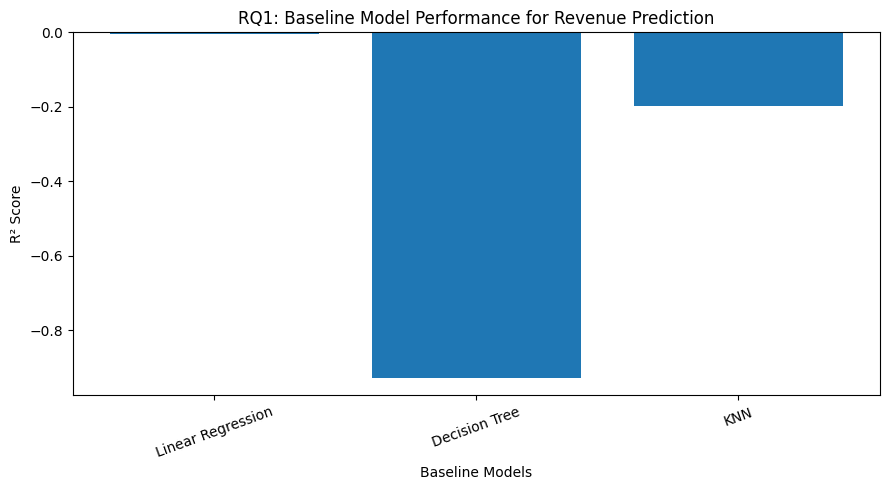

In [10]:
plt.figure(figsize=(9, 5))

plt.bar(results_df['Model'], results_df['R2'])

plt.xlabel('Baseline Models')
plt.ylabel('R² Score')
plt.title('RQ1: Baseline Model Performance for Revenue Prediction')
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig('RQ1_Baseline_Model_Performance.pdf')
plt.show()

## Conclusion

The baseline regression models were trained to predict Revenue_Generated using marketing and product performance features. The results show how simple supervised learning models perform before applying advanced models. This establishes a baseline for comparison in the next research question.